In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import norm

# AAPL

In [2]:
# load the two saved models
xgb_model = joblib.load("xgb_aapl_model.pkl")
nn_model = joblib.load("nn_aapl_model.pkl")
nn_scaler = joblib.load("nn_aapl_scaler.pkl")

print("xgb loaded:", type(xgb_model))
print("nn loaded:", type(nn_model))
print("scaler loaded:", type(nn_scaler))

xgb loaded: <class 'xgboost.sklearn.XGBRegressor'>
nn loaded: <class 'sklearn.neural_network._multilayer_perceptron.MLPRegressor'>
scaler loaded: <class 'sklearn.preprocessing._data.StandardScaler'>


In [3]:
# synthetic grid: vary moneyness only, other inputs fixed at training medians
K_fixed = 136.0
T_fixed = 0.194521
r_fixed = 0.008786
q_fixed = 0.004492
sigma_fixed = 0.281015

moneyness_grid = np.linspace(0.3, 20, 400)
S_grid = moneyness_grid * K_fixed   # S = moneyness * K

train_boundary = 4.75   # 99th percentile of training moneyness (effective training limit)

print("grid shape:", moneyness_grid.shape)
print("moneyness range:", moneyness_grid.min(), "to", moneyness_grid.max())

grid shape: (400,)
moneyness range: 0.3 to 20.0


In [14]:
# synthetic grid v2: fix S at a realistic level, vary K to obtain moneyness
S_fixed = 200.0        # realistic AAPL level in the sample
T_fixed = 0.194521
r_fixed = 0.008786
q_fixed = 0.004492
sigma_fixed = 0.281015

moneyness_grid = np.linspace(0.3, 20, 400)
K_grid = S_fixed / moneyness_grid      # K decreases as moneyness increases (as in real data)

train_boundary = 4.75   # 99th percentile of training moneyness

print("moneyness range:", moneyness_grid.min().round(2), "to", moneyness_grid.max().round(2))
print("implied K range:", K_grid.min().round(2), "to", K_grid.max().round(2))

moneyness range: 0.3 to 20.0
implied K range: 10.0 to 666.67


In [15]:
# Black-Scholes on the corrected grid
d1 = (np.log(S_fixed / K_grid) + (r_fixed - q_fixed + 0.5 * sigma_fixed**2) * T_fixed) / (sigma_fixed * np.sqrt(T_fixed))
d2 = d1 - sigma_fixed * np.sqrt(T_fixed)
bs_price = S_fixed * np.exp(-q_fixed * T_fixed) * norm.cdf(d1) - K_grid * np.exp(-r_fixed * T_fixed) * norm.cdf(d2)
bs_price_norm = bs_price / K_grid

In [16]:
X_grid_xgb = pd.DataFrame({
    "moneyness (S/K)": moneyness_grid, "T": T_fixed, "rate": r_fixed,
    "q": q_fixed, "volatility": sigma_fixed
})
xgb_pred_price = xgb_model.predict(X_grid_xgb)
xgb_pred_norm = xgb_pred_price / K_grid

In [19]:
xgb_v5_model = joblib.load("xgb_v5_aapl_model.pkl")

# v5 predicts log1p(price/K) — expm1 already gives the normalized price
X_grid_v5 = pd.DataFrame({
    "moneyness (S/K)": moneyness_grid, "T": T_fixed, "rate": r_fixed,
    "q": q_fixed, "volatility": sigma_fixed
})
xgb_v5_pred_norm = np.expm1(xgb_v5_model.predict(X_grid_v5))

print("v5 sample:", xgb_v5_pred_norm[:3], "...", xgb_v5_pred_norm[-3:])

v5 sample: [0.00306784 0.00306784 0.00306784] ... [4.918848 4.918848 4.918848]


In [20]:
X_grid_nn = pd.DataFrame({
    "moneyness (S/K)": moneyness_grid, "strike_price": K_grid, "T": T_fixed,
    "rate": r_fixed, "q": q_fixed, "volatility": sigma_fixed
})
X_grid_nn_scaled = nn_scaler.transform(X_grid_nn)
nn_pred_norm = np.expm1(nn_model.predict(X_grid_nn_scaled))

c:\Users\glmar\OneDrive\Bemacs Bocconi\TESI\Thesis\Priced-by-intelligence\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


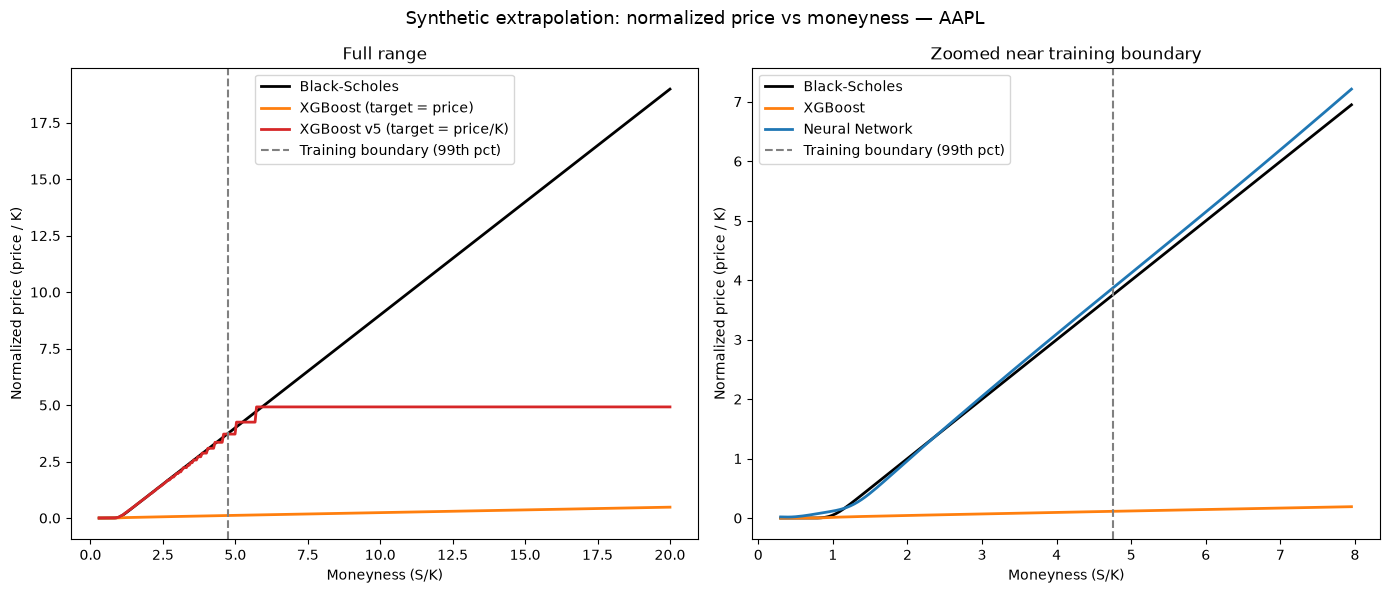

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left panel: full range
axes[0].plot(moneyness_grid, bs_price_norm, label="Black-Scholes", color="black", linewidth=2)
axes[0].plot(moneyness_grid, xgb_pred_norm, label="XGBoost (target = price)", color="tab:orange", linewidth=2)
axes[0].plot(moneyness_grid, xgb_v5_pred_norm, label="XGBoost v5 (target = price/K)", color="tab:red", linewidth=2)
axes[0].axvline(train_boundary, color="gray", linestyle="--", linewidth=1.5, label="Training boundary (99th pct)")
axes[0].set_xlabel("Moneyness (S/K)")
axes[0].set_ylabel("Normalized price (price / K)")
axes[0].set_title("Full range")
axes[0].legend()

# right panel: zoomed near the training boundary
zoom_mask = moneyness_grid <= 8
axes[1].plot(moneyness_grid[zoom_mask], bs_price_norm[zoom_mask], label="Black-Scholes", color="black", linewidth=2)
axes[1].plot(moneyness_grid[zoom_mask], xgb_pred_norm[zoom_mask], label="XGBoost", color="tab:orange", linewidth=2)
axes[1].plot(moneyness_grid[zoom_mask], nn_pred_norm[zoom_mask], label="Neural Network", color="tab:blue", linewidth=2)
axes[1].axvline(train_boundary, color="gray", linestyle="--", linewidth=1.5, label="Training boundary (99th pct)")
axes[1].set_xlabel("Moneyness (S/K)")
axes[1].set_ylabel("Normalized price (price / K)")
axes[1].set_title("Zoomed near training boundary")
axes[1].legend()

fig.suptitle("Synthetic extrapolation: normalized price vs moneyness — AAPL", fontsize=13)
plt.tight_layout()
plt.savefig("extrapolation_chart_aapl.png", dpi=150)
plt.show()

In [26]:
# check XGBoost prediction at specific moneyness values to see the actual shape
check_points = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 4.0, 4.75, 6.0, 8.0, 10.0, 15.0, 20.0]

for m in check_points:
    S_check = m * K_fixed
    X_check = pd.DataFrame({
        "moneyness (S/K)": [m], "T": [T_fixed], "rate": [r_fixed],
        "q": [q_fixed], "volatility": [sigma_fixed]
    })
    pred = xgb_model.predict(X_check)[0]
    pred_norm = pred / K_fixed
    print(f"moneyness={m:>6.2f}  ->  xgb price={pred:>8.4f}  normalized={pred_norm:.5f}")

moneyness=  0.50  ->  xgb price=  0.0238  normalized=0.00018
moneyness=  0.80  ->  xgb price=  0.4691  normalized=0.00345
moneyness=  1.00  ->  xgb price=  2.4025  normalized=0.01767
moneyness=  1.20  ->  xgb price=  3.3572  normalized=0.02469
moneyness=  1.50  ->  xgb price=  3.9508  normalized=0.02905
moneyness=  2.00  ->  xgb price=  4.3421  normalized=0.03193
moneyness=  3.00  ->  xgb price=  4.6213  normalized=0.03398
moneyness=  4.00  ->  xgb price=  4.7220  normalized=0.03472
moneyness=  4.75  ->  xgb price=  4.7766  normalized=0.03512
moneyness=  6.00  ->  xgb price=  4.8023  normalized=0.03531
moneyness=  8.00  ->  xgb price=  4.8023  normalized=0.03531
moneyness= 10.00  ->  xgb price=  4.8163  normalized=0.03541
moneyness= 15.00  ->  xgb price=  4.8163  normalized=0.03541
moneyness= 20.00  ->  xgb price=  4.8163  normalized=0.03541


## XGBoost behaviour on the synthetic extrapolation grid

The synthetic grid fixes the underlying price at a realistic level (S = 200) and varies the
strike, so that increasing moneyness is obtained the same way it arises in the data: through
progressively lower strikes. All remaining inputs (T, r, q, sigma) are held at their training-sample
medians. This is a diagnostic experiment on synthetic inputs, not an empirical result.

Black-Scholes and the normalized-target neural network both track the intrinsic-value line
closely across the entire moneyness range, including well beyond the effective training boundary
(moneyness = 4.75, the 99th percentile of the training sample). XGBoost does not: its normalized
prediction (price / K) stays close to zero throughout, rising from roughly 0 to only 0.5 while the
Black-Scholes curve reaches approximately 19 at the right edge of the grid.

The mechanism is a failure of scale, not of shape. XGBoost is trained on the absolute price with
moneyness, T, r, q and sigma as inputs, and therefore never observes the strike. Two contracts with
identical moneyness but different strikes — one with K = 20 worth roughly 180, one with K = 2 worth
roughly 18 — are indistinguishable to the model, which converges to a single fitted value for the
group. Because deep-ITM observations are sparse (under 1% of the training sample lies beyond
moneyness 5) and concentrated at low strikes, that fitted value is small in absolute terms. Dividing
it by a strike that shrinks as moneyness grows produces the flat normalized curve seen in the figure.

Supplying the strike as an additional input does not resolve this. In the exploratory phase, a
specification adding strike_price to the feature set (v4) produced only a modest and inconsistent
improvement across the two underlyings, and was not retained. Providing K as a feature allows the
model to learn the price-strike relationship from data, but does not impose it: the tree must
recover degree-one homogeneity through a finite sequence of axis-aligned splits, which sparse
deep-ITM data cannot support. The constraint has to enter through the formulation of the target,
not through the feature set — which is precisely what normalizing the target by K achieves for the
neural network, following Hutchinson, Lo and Poggio (1994) and Garcia and Gencay (2000).

# SPX